# Development for identifying weather events relevant to snow metamorphism
S. Filhol 2024


Type of weather to identify:
- above freezing temperature
- wind speed above 6m/s
- precipitation



In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
plt.style.use('/home/simonfi/github/myDotFiles/matplotlib_style/style_IoT.mplstyle')
import warnings, os
warnings.filterwarnings('ignore')

In [82]:
obs = pd.read_csv('../../TPS_job/tps_nyalesund/inputs/observation/20231001_20240330_metno_obs.csv')
obs.rename(columns={'Name':'name', 'Station':'station', 'Time(norwegian mean time)':'time', 'Precipitation (1 h)':'tp',
       'Air temperature':'t', 'Wind direction':'wd', 'Mean wind speed':'ws', 'Snow depth':'sd',
       'Air pressure at station level':'p', 'Relative air humidity':'rh'}, inplace=True)
obs.set_index(pd.to_datetime(obs.time, format='%d.%m.%Y %H:%M'), inplace=True)

obs_daily = obs[['t', 'ws', 'sd', 'rh', 'p']].resample('12H').mean()

In [83]:
obs_daily['t_below_freezing'] = obs_daily.t * (obs_daily.t <=0)
obs_daily['ws_above_drifting'] = obs_daily.ws * ((obs_daily.ws >=6)) 

obs_daily['ws_below_drifting'] = 6
obs_daily.ws_below_drifting.loc[obs_daily.ws<=6] = obs_daily.ws.loc[obs_daily.ws<=6]


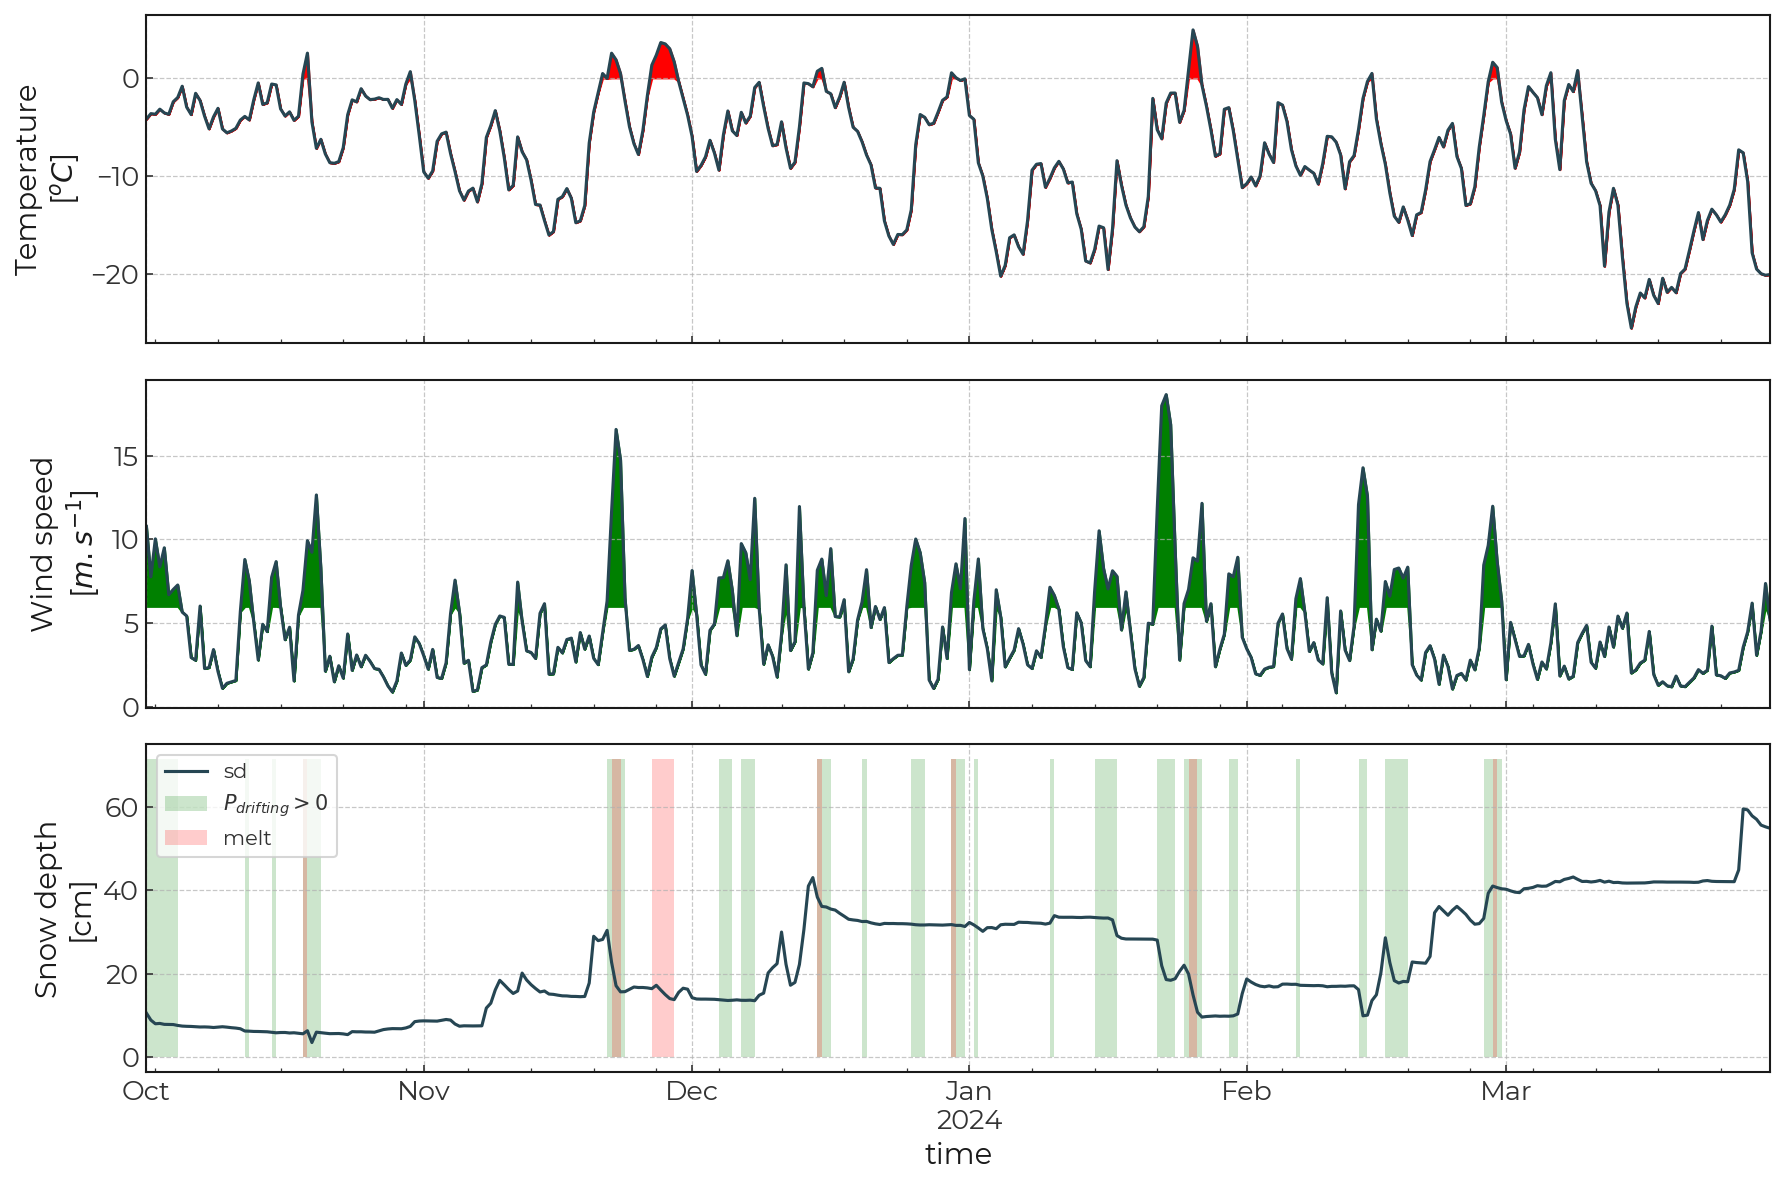

In [96]:
fig, ax = plt.subplots(3,1, sharex=True, figsize=(12,8))

# temperature
obs_daily.t.plot(ax=ax[0])
ax[0].fill_between(obs_daily.index, obs_daily.t_below_freezing, obs_daily.t, color='r')
ax[0].set_ylabel('Temperature\n[$^{o}C$]')



# wind
obs_daily.ws.plot(ax=ax[1])
#obs_daily.ws_below_drifting.plot(ax=ax[1])
ax[1].fill_between(obs_daily.index, obs_daily.ws_below_drifting, obs_daily.ws, color='g')
ax[1].set_ylabel('Wind speed\n[$m.s^{-1}$]')


# snow depth
obs_daily.sd.plot(ax=ax[2], label=None)
ax[2].fill_between(obs_daily.index, 0, obs_daily.sd.max()*1.2, where=obs_daily.ws>=6, color='g', alpha=0.2, edgecolor=None, label='$P_{drifting}>0$')
ax[2].fill_between(obs_daily.index, 0, obs_daily.sd.max()*1.2, where=obs_daily.t>=0, color='r', alpha=0.2, edgecolor=None, label='melt')
ax[2].legend()
ax[2].set_ylabel('Snow depth\n[cm]')

plt.tight_layout()


In [98]:
import weather

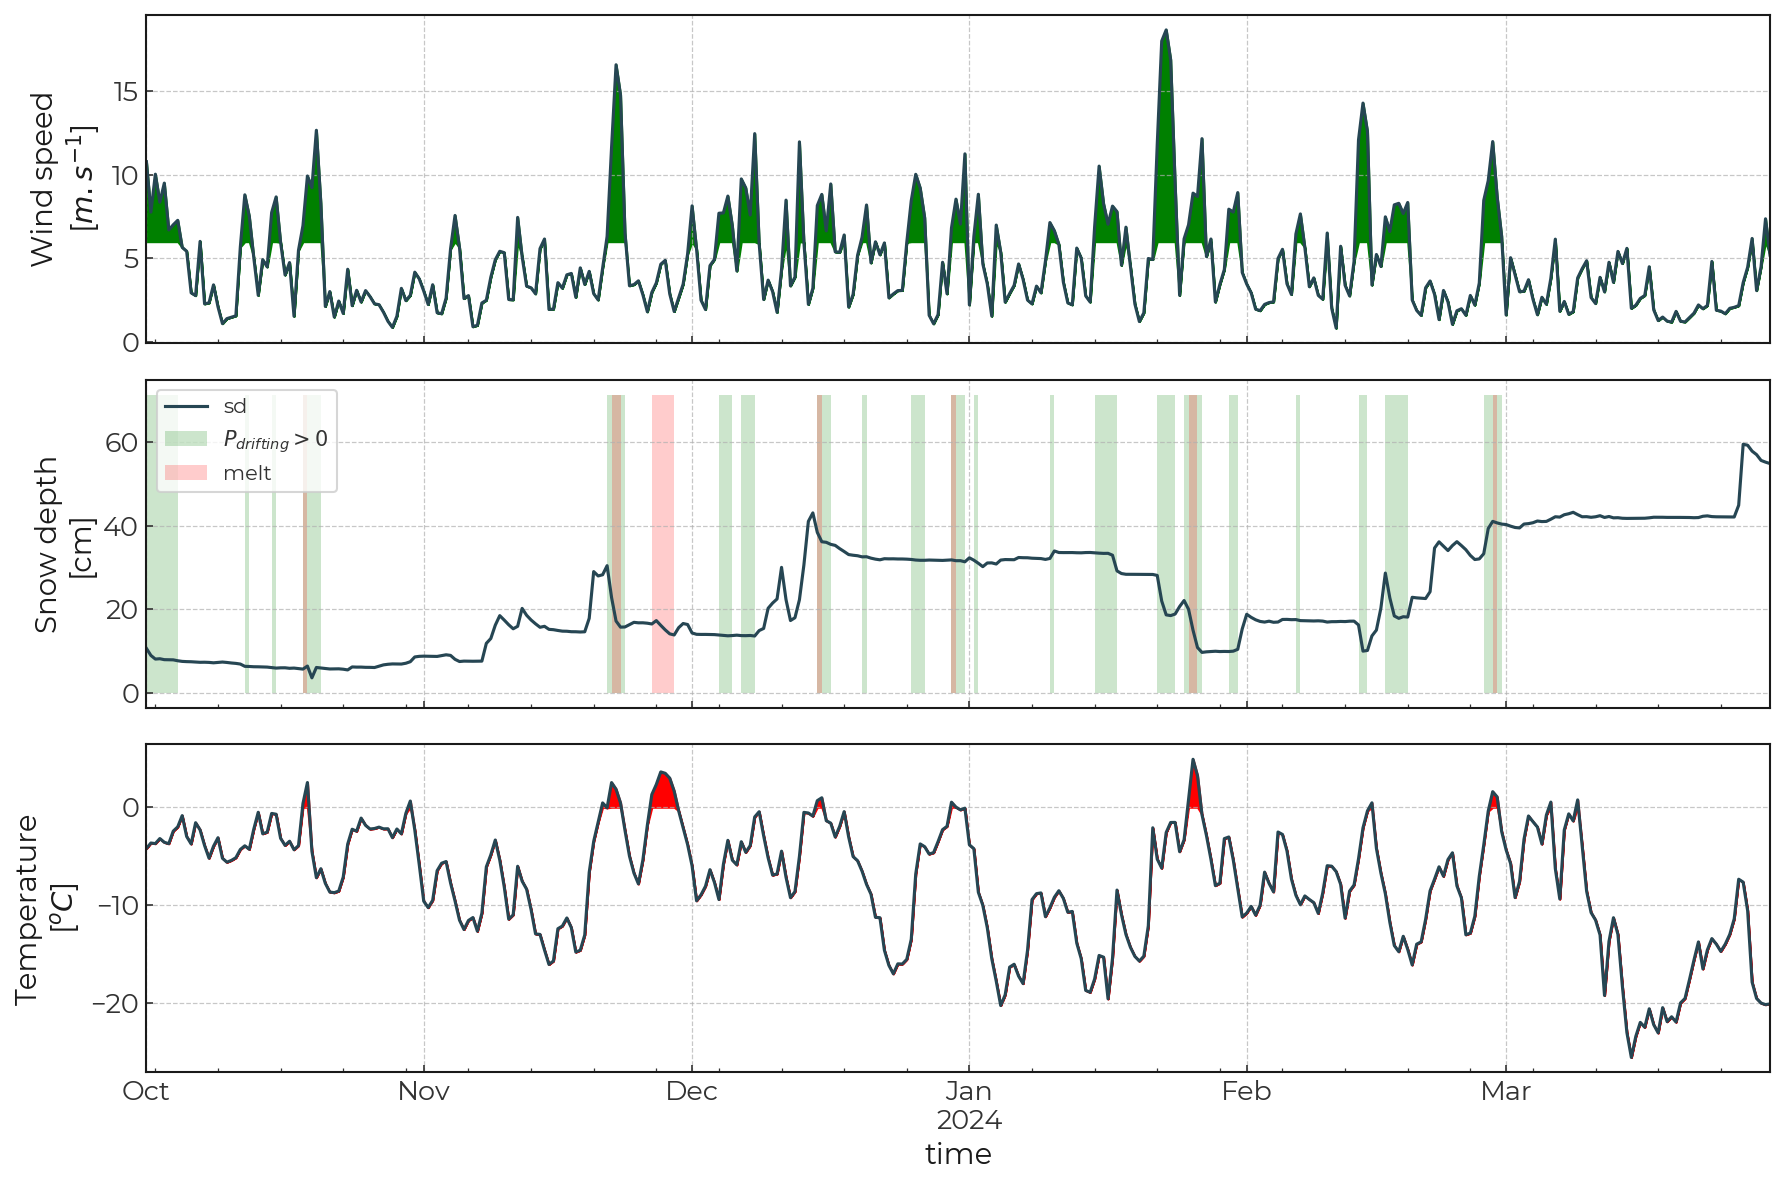

In [101]:
weather.plot_weather_history(obs[['t', 'ws', 'sd', 'rh', 'p']], var_to_plot=['ws', 'sd', 't'])